# Advanced Frog Species Prediction Model
## Using TerraClimate Variables for Binary Classification

This notebook builds a machine learning classification model to predict frog species presence based on TerraClimate climate variables. The model uses advanced feature engineering, multiple algorithms, and proper cross-validation to achieve high F1 Score performance.

## Section 1: Import Required Libraries

Import necessary libraries for data science, machine learning, and data manipulation.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import joblib
import os

# Machine Learning
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix,
    precision_score, recall_score
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Gradient boosting libraries
import lightgbm as lgb
import xgboost as xgb
import optuna

# For climate data
import xarray as xr
import rasterio

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("All libraries imported successfully!")

All libraries imported successfully!


## Section 2: Load and Explore the Data

Load the training and test datasets from CSV files and understand their structure.

In [2]:
# Load training and test data
train_data = pd.read_csv('Training_Data.csv')
test_data = pd.read_csv('Test.csv')

print("Training Data Shape:", train_data.shape)
print("\nTraining Data Info:")
print(train_data.head())
print("\nTarget Distribution:")
print(train_data['Occurrence Status'].value_counts())
print("\nClass Balance:")
print(train_data['Occurrence Status'].value_counts(normalize=True))

print("\n" + "="*50)
print("Test Data Shape:", test_data.shape)
print("Test Data Info:")
print(test_data.head())

Training Data Shape: (6312, 4)

Training Data Info:
             ID   Latitude   Longitude  Occurrence Status
0  ID_TR_957A5A -34.027900  150.771000                  1
1  ID_TR_55E0AF -34.821595  147.193697                  1
2  ID_TR_7AC931 -36.617759  146.882941                  0
3  ID_TR_7D3CE4 -37.470900  144.744000                  1
4  ID_TR_02F669 -38.400153  145.018560                  1

Target Distribution:
Occurrence Status
1    3792
0    2520
Name: count, dtype: int64

Class Balance:
Occurrence Status
1    0.60076
0    0.39924
Name: proportion, dtype: float64

Test Data Shape: (2000, 3)
Test Data Info:
             ID   Latitude   Longitude
0  ID_TS_54240C -33.121788  150.320746
1  ID_TS_EF9635 -36.592011  148.172262
2  ID_TS_4E63E6 -35.455100  146.693465
3  ID_TS_FDAB8E -33.076261  149.547177
4  ID_TS_E00D49 -35.529729  146.627272


## Section 3: Extract TerraClimate Variables

Define a function to extract TerraClimate climate variables from GeoTIFF files using lat/lon coordinates.

In [3]:
def extract_climate_features(tiff_path, csv_df, band_names):
    """
    Extract ALL climate variables from GeoTIFF file at specified lat/lon locations.
    Reads band_names from band_names.json generated by TerraClimate.ipynb.
    """
    with rasterio.open(tiff_path) as dataset:
        lon = np.linspace(dataset.bounds.left, dataset.bounds.right, dataset.width)
        lat = np.linspace(dataset.bounds.top, dataset.bounds.bottom, dataset.height)

        climate_arrays = {}
        for i, band_name in enumerate(band_names, 1):
            if i > dataset.count:
                print(f"Warning: Band {i} ({band_name}) not available. Skipping.")
                continue
            raster_data = dataset.read(i)
            da = xr.DataArray(
                raster_data,
                coords=[("lat", lat), ("lon", lon)],
                dims=["lat", "lon"]
            )
            climate_arrays[band_name] = da

    extracted = {name: [] for name in climate_arrays}

    for _, row in tqdm(csv_df.iterrows(), total=len(csv_df), desc="Extracting climate data"):
        target_lat, target_lon = row["Latitude"], row["Longitude"]
        for band_name, da in climate_arrays.items():
            try:
                val = da.sel(lat=target_lat, lon=target_lon, method="nearest").values
                extracted[band_name].append(float(val))
            except Exception:
                extracted[band_name].append(np.nan)

    return pd.DataFrame(extracted)


# Load band names from JSON (generated by TerraClimate.ipynb)
tiff_path = 'TerraClimate_output.tiff'
band_names_file = 'band_names.json'

if os.path.exists(tiff_path) and os.path.exists(band_names_file):
    with open(band_names_file) as f:
        band_names = json.load(f)
    print(f"GeoTIFF found with {len(band_names)} bands: {band_names}")

    train_climate = extract_climate_features(tiff_path, train_data, band_names)
    test_climate = extract_climate_features(tiff_path, test_data, band_names)

    print(f"\nTrain climate shape: {train_climate.shape}")
    print(f"Test climate shape:  {test_climate.shape}")
    print(train_climate.describe())
elif os.path.exists(tiff_path):
    # Fallback: no band_names.json — read whatever bands exist
    with rasterio.open(tiff_path) as src:
        n_bands = src.count
    band_names = [f"band_{i}" for i in range(1, n_bands + 1)]
    print(f"No band_names.json found. Reading {n_bands} bands with generic names.")

    train_climate = extract_climate_features(tiff_path, train_data, band_names)
    test_climate = extract_climate_features(tiff_path, test_data, band_names)
else:
    print("ERROR: TerraClimate_output.tiff not found!")
    print("Please run TerraClimate.ipynb first to generate the GeoTIFF.")
    train_climate = pd.DataFrame()
    test_climate = pd.DataFrame()

GeoTIFF found with 28 bands: ['aet_median', 'def_median', 'pdsi_median', 'pet_median', 'ppt_median', 'q_median', 'soil_median', 'srad_median', 'swe_median', 'tmax_median', 'tmin_median', 'vap_median', 'vpd_median', 'ws_median', 'aet_std', 'def_std', 'pdsi_std', 'pet_std', 'ppt_std', 'q_std', 'soil_std', 'srad_std', 'swe_std', 'tmax_std', 'tmin_std', 'vap_std', 'vpd_std', 'ws_std']


Extracting climate data: 100%|██████████| 2000/2000 [00:36<00:00, 54.66it/s]



Train climate shape: (6312, 28)
Test climate shape:  (2000, 28)
        aet_median   def_median  pdsi_median   pet_median   ppt_median  \
count  6312.000000  6312.000000  6312.000000  6312.000000  6312.000000   
mean     42.468949    66.832225    -4.205925   120.981640    47.162722   
std      14.310979    35.670742     0.781642    16.712783    18.748566   
min       9.600000     0.000000    -6.500000    78.599998    10.100000   
25%      33.200001    40.299999    -4.700000   109.074999    34.000000   
50%      42.500000    61.400002    -4.400000   116.099998    45.000000   
75%      51.799999    90.599998    -3.800000   130.199997    59.025000   
max      96.599998   148.400009    -2.300000   164.699997   127.800000   

          q_median  soil_median  srad_median   swe_median  tmax_median  \
count  6312.000000  6312.000000  6312.000000  6312.000000  6312.000000   
mean      2.426061    22.674858   206.006832     0.000111    21.773526   
std       1.285706    31.136363    12.158110  

## Section 4: Preprocess and Engineer Features

Combine climate features with ground truth data, handle missing values, and prepare features for modeling.

In [4]:
def create_combined_dataset(climate_df, ground_df, include_coords=True):
    """Combine climate features with ground truth data, optionally keep lat/lon as features."""
    combined = pd.concat([ground_df.reset_index(drop=True), climate_df.reset_index(drop=True)], axis=1)

    # Fill missing climate values with column median
    numeric_cols = combined.select_dtypes(include=[np.number]).columns
    combined[numeric_cols] = combined[numeric_cols].fillna(combined[numeric_cols].median())

    if not include_coords:
        combined = combined.drop(columns=['Latitude', 'Longitude'], errors='ignore')

    return combined


# Build combined datasets — KEEP lat/lon as features (geographic position is predictive)
if len(train_climate) > 0:
    X_train_combined = create_combined_dataset(train_climate, train_data, include_coords=True)
    X_test_combined = create_combined_dataset(test_climate, test_data, include_coords=True)
else:
    X_train_combined = train_data.copy()
    X_test_combined = test_data.copy()

print("Combined Training Data Shape:", X_train_combined.shape)
print("Columns:", X_train_combined.columns.tolist())

Combined Training Data Shape: (6312, 32)
Columns: ['ID', 'Latitude', 'Longitude', 'Occurrence Status', 'aet_median', 'def_median', 'pdsi_median', 'pet_median', 'ppt_median', 'q_median', 'soil_median', 'srad_median', 'swe_median', 'tmax_median', 'tmin_median', 'vap_median', 'vpd_median', 'ws_median', 'aet_std', 'def_std', 'pdsi_std', 'pet_std', 'ppt_std', 'q_std', 'soil_std', 'srad_std', 'swe_std', 'tmax_std', 'tmin_std', 'vap_std', 'vpd_std', 'ws_std']


In [5]:
# Prepare X and y — include Latitude/Longitude as features, exclude ID and target
exclude_cols = ['ID', 'Occurrence Status']
feature_cols = [c for c in X_train_combined.columns if c not in exclude_cols]

X = X_train_combined[feature_cols].copy()
y = X_train_combined['Occurrence Status'].copy()

test_ids = X_test_combined['ID'].copy()
X_test_final = X_test_combined[feature_cols].copy()

print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"Training: {X.shape}, Test: {X_test_final.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"Imbalance ratio: {y.value_counts()[0] / y.value_counts()[1]:.2f}:1")

Features (30): ['Latitude', 'Longitude', 'aet_median', 'def_median', 'pdsi_median', 'pet_median', 'ppt_median', 'q_median', 'soil_median', 'srad_median', 'swe_median', 'tmax_median', 'tmin_median', 'vap_median', 'vpd_median', 'ws_median', 'aet_std', 'def_std', 'pdsi_std', 'pet_std', 'ppt_std', 'q_std', 'soil_std', 'srad_std', 'swe_std', 'tmax_std', 'tmin_std', 'vap_std', 'vpd_std', 'ws_std']
Training: (6312, 30), Test: (2000, 30)
Target distribution:
Occurrence Status
1    3792
0    2520
Name: count, dtype: int64
Imbalance ratio: 0.66:1


## Section 4b: Spatial KNN Features

Compute occurrence-based spatial features using K-Nearest Neighbors with haversine distance. This captures the strong spatial autocorrelation of frog presence — nearby locations tend to have similar occurrence patterns.

In [6]:
# ============================================================
# SPATIAL KNN FEATURES (Occurrence-based)
# ============================================================
from sklearn.neighbors import BallTree

print("=" * 60)
print("COMPUTING SPATIAL KNN FEATURES")
print("=" * 60)

def compute_knn_features(ref_coords, ref_labels, query_coords, k_values=[5, 10, 25, 50, 100],
                          exclude_self=False):
    """
    Compute KNN-based spatial features using haversine distance.
    
    ref_coords: DataFrame with Latitude, Longitude columns (reference/training points)
    ref_labels: Series of binary labels for reference points
    query_coords: DataFrame with Latitude, Longitude columns (points to compute features for)
    k_values: list of K values for KNN
    exclude_self: True for leave-one-out (when query == reference)
    """
    ref_arr = ref_coords[['Latitude', 'Longitude']].values
    query_arr = query_coords[['Latitude', 'Longitude']].values
    ref_rad = np.radians(ref_arr)
    query_rad = np.radians(query_arr)
    labels_arr = ref_labels.values if hasattr(ref_labels, 'values') else np.array(ref_labels)
    
    # Build BallTree with haversine metric
    tree = BallTree(ref_rad, metric='haversine')
    max_k = max(k_values) + (1 if exclude_self else 0)
    max_k = min(max_k, len(ref_rad))
    distances, indices = tree.query(query_rad, k=max_k)
    
    offset = 1 if exclude_self else 0
    distances_km = distances * 6371.0  # Earth radius in km
    
    features = {}
    for k in k_values:
        if k + offset > distances.shape[1]:
            continue
        k_dists = distances_km[:, offset:k+offset]
        k_idx = indices[:, offset:k+offset]
        k_labels = labels_arr[k_idx]
        
        features[f'knn_{k}_occ_mean'] = k_labels.mean(axis=1)
        features[f'knn_{k}_occ_std'] = k_labels.std(axis=1)
        features[f'knn_{k}_dist_mean'] = k_dists.mean(axis=1)
        features[f'knn_{k}_dist_min'] = k_dists[:, 0]
        features[f'knn_{k}_weighted_occ'] = np.average(
            k_labels, axis=1, weights=1.0 / (k_dists + 0.01)
        )
    
    # Distance to nearest positive and negative occurrence
    for label_val, label_name in [(1, 'pos'), (0, 'neg')]:
        mask = labels_arr == label_val
        if mask.sum() < 2:
            continue
        sub_rad = ref_rad[mask]
        sub_tree = BallTree(sub_rad, metric='haversine')
        
        if exclude_self:
            sub_dist, _ = sub_tree.query(query_rad, k=min(2, mask.sum()))
            is_same = np.zeros(len(query_rad), dtype=bool)
            if len(labels_arr) == len(query_rad):
                is_same = labels_arr == label_val
            features[f'dist_nearest_{label_name}_km'] = np.where(
                is_same,
                sub_dist[:, min(1, sub_dist.shape[1]-1)] * 6371.0,
                sub_dist[:, 0] * 6371.0
            )
        else:
            sub_dist, _ = sub_tree.query(query_rad, k=1)
            features[f'dist_nearest_{label_name}_km'] = sub_dist[:, 0] * 6371.0
    
    # Derived: ratio and difference of distances to positive vs negative
    if 'dist_nearest_pos_km' in features and 'dist_nearest_neg_km' in features:
        features['dist_ratio_pos_neg'] = (
            features['dist_nearest_pos_km'] / (features['dist_nearest_neg_km'] + 0.01)
        )
        features['dist_diff_pos_neg'] = (
            features['dist_nearest_pos_km'] - features['dist_nearest_neg_km']
        )
    
    return pd.DataFrame(features)

# Compute spatial KNN features
train_coords = X[['Latitude', 'Longitude']]
test_coords = X_test_final[['Latitude', 'Longitude']]

# Training data: leave-one-out (exclude self as nearest neighbor)
print("Computing KNN features for training data (leave-one-out)...")
train_knn = compute_knn_features(X, y, X, exclude_self=True)

# Test data: use all training data as reference
print("Computing KNN features for test data...")
test_knn = compute_knn_features(X, y, X_test_final, exclude_self=False)

# Append KNN features to X and X_test_final
X = pd.concat([X.reset_index(drop=True), train_knn.reset_index(drop=True)], axis=1)
X_test_final = pd.concat([X_test_final.reset_index(drop=True), test_knn.reset_index(drop=True)], axis=1)

# Update feature_cols to include KNN features
feature_cols = X.columns.tolist()

print(f"\nKNN features added ({len(train_knn.columns)}): {train_knn.columns.tolist()}")
print(f"Total features now: {len(feature_cols)}")
print(f"Training shape: {X.shape}, Test shape: {X_test_final.shape}")
print(f"\nSample KNN values (first 5 rows):")
print(train_knn.head())

COMPUTING SPATIAL KNN FEATURES
Computing KNN features for training data (leave-one-out)...
Computing KNN features for test data...

KNN features added (29): ['knn_5_occ_mean', 'knn_5_occ_std', 'knn_5_dist_mean', 'knn_5_dist_min', 'knn_5_weighted_occ', 'knn_10_occ_mean', 'knn_10_occ_std', 'knn_10_dist_mean', 'knn_10_dist_min', 'knn_10_weighted_occ', 'knn_25_occ_mean', 'knn_25_occ_std', 'knn_25_dist_mean', 'knn_25_dist_min', 'knn_25_weighted_occ', 'knn_50_occ_mean', 'knn_50_occ_std', 'knn_50_dist_mean', 'knn_50_dist_min', 'knn_50_weighted_occ', 'knn_100_occ_mean', 'knn_100_occ_std', 'knn_100_dist_mean', 'knn_100_dist_min', 'knn_100_weighted_occ', 'dist_nearest_pos_km', 'dist_nearest_neg_km', 'dist_ratio_pos_neg', 'dist_diff_pos_neg']
Total features now: 59
Training shape: (6312, 59), Test shape: (2000, 59)

Sample KNN values (first 5 rows):
   knn_5_occ_mean  knn_5_occ_std  knn_5_dist_mean  knn_5_dist_min  \
0             1.0       0.000000         3.957060        3.518978   
1          

## Section 5: Split Data into Training and Validation Sets

Partition the training data into train and validation subsets using stratified split to maintain class balance.

In [7]:
# Stratified train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape},  Val: {X_val.shape}")
print(f"Train dist:\n{y_train.value_counts(normalize=True)}")
print(f"Val dist:\n{y_val.value_counts(normalize=True)}")

Train: (5049, 59),  Val: (1263, 59)
Train dist:
Occurrence Status
1    0.600713
0    0.399287
Name: proportion, dtype: float64
Val dist:
Occurrence Status
1    0.60095
0    0.39905
Name: proportion, dtype: float64


## Section 6: Feature Engineering

Create derived features from climate variables to improve model discrimination.

In [ ]:
def engineer_features(df, base_feature_cols):
    """Create derived features from base climate, spatial, and KNN columns."""
    out = df.copy()

    # Separate median and std columns
    median_cols = [c for c in base_feature_cols if c.endswith('_median')]
    std_cols = [c for c in base_feature_cols if c.endswith('_std')]
    climate_cols = median_cols if median_cols else [
        c for c in base_feature_cols if c not in ['Latitude', 'Longitude']
    ]

    def has_cols(*cols):
        return all(col in out.columns for col in cols)

    # 1. Aggregate statistics across all median climate features
    if len(climate_cols) >= 2:
        out['climate_mean'] = out[climate_cols].mean(axis=1)
        out['climate_std'] = out[climate_cols].std(axis=1)
        out['climate_range'] = out[climate_cols].max(axis=1) - out[climate_cols].min(axis=1)
        out['climate_cv'] = out['climate_std'] / (out['climate_mean'].abs() + 1e-8)
        out['climate_skew_proxy'] = (out['climate_mean'] - out[climate_cols].median(axis=1))
    if len(std_cols) >= 2:
        out['climate_variability_mean'] = out[std_cols].mean(axis=1)
        out['climate_variability_max'] = out[std_cols].max(axis=1)

    # 2. Geography features
    if has_cols('Latitude', 'Longitude'):
        out['lat_lon_interaction'] = out['Latitude'] * out['Longitude']
        out['lat_abs'] = out['Latitude'].abs()
        out['lon_abs'] = out['Longitude'].abs()
        out['lat_sin'] = np.sin(np.radians(out['Latitude']))
        out['lat_cos'] = np.cos(np.radians(out['Latitude']))
        out['lon_sin'] = np.sin(np.radians(out['Longitude']))
        out['lon_cos'] = np.cos(np.radians(out['Longitude']))
        out['geo_radius'] = np.sqrt(out['Latitude'] ** 2 + out['Longitude'] ** 2)

    # 3. Ratio of std to median (temporal variability relative to level)
    for mc in median_cols:
        var_base = mc.replace('_median', '')
        sc = f"{var_base}_std"
        if sc in out.columns:
            out[f"{var_base}_cv"] = out[sc] / (out[mc].abs() + 1e-8)

    # 4. Domain-driven hydrology and temperature signals
    if has_cols('tmax_median', 'tmin_median'):
        out['temp_mean'] = (out['tmax_median'] + out['tmin_median']) / 2.0
        out['temp_range'] = out['tmax_median'] - out['tmin_median']
    if has_cols('tmax_std', 'tmin_std'):
        out['temp_range_std'] = out['tmax_std'] - out['tmin_std']
    if has_cols('ppt_median', 'pet_median'):
        out['water_balance'] = out['ppt_median'] - out['pet_median']
        out['aridity_ratio'] = out['pet_median'] / (out['ppt_median'].abs() + 1e-8)
    if has_cols('aet_median', 'pet_median'):
        out['aet_pet_ratio'] = out['aet_median'] / (out['pet_median'].abs() + 1e-8)
    if has_cols('aet_median', 'ppt_median'):
        out['aet_ppt_ratio'] = out['aet_median'] / (out['ppt_median'].abs() + 1e-8)
    if has_cols('soil_median', 'ppt_median'):
        out['soil_ppt_ratio'] = out['soil_median'] / (out['ppt_median'].abs() + 1e-8)
    if has_cols('vap_median', 'vpd_median'):
        out['vap_vpd_gap'] = out['vap_median'] - out['vpd_median']
        out['vap_vpd_ratio'] = out['vap_median'] / (out['vpd_median'].abs() + 1e-8)
    if has_cols('srad_median', 'ws_median'):
        out['radiation_wind_interaction'] = out['srad_median'] * out['ws_median']
    if has_cols('srad_median', 'tmax_median', 'tmin_median'):
        temp_mean = (out['tmax_median'] + out['tmin_median']) / 2.0
        out['energy_temp_interaction'] = out['srad_median'] * temp_mean

    # 5. KNN summary features and climate-spatial interactions
    knn_occ_cols = [c for c in out.columns if c.startswith('knn_') and c.endswith('_occ_mean')]
    knn_dist_cols = [c for c in out.columns if c.startswith('knn_') and c.endswith('_dist_mean')]
    if knn_occ_cols:
        out['knn_occ_mean_avg'] = out[knn_occ_cols].mean(axis=1)
        out['knn_occ_mean_max'] = out[knn_occ_cols].max(axis=1)
    if knn_dist_cols:
        out['knn_dist_mean_avg'] = out[knn_dist_cols].mean(axis=1)
        out['knn_dist_mean_min'] = out[knn_dist_cols].min(axis=1)
    if has_cols('knn_25_occ_mean', 'ppt_median'):
        out['ppt_knn25_interaction'] = out['ppt_median'] * out['knn_25_occ_mean']
    if has_cols('knn_25_occ_mean', 'temp_range'):
        out['temp_range_knn25_interaction'] = out['temp_range'] * out['knn_25_occ_mean']
    if has_cols('dist_nearest_pos_km', 'dist_nearest_neg_km'):
        out['log_dist_ratio_pos_neg'] = np.log1p(out['dist_nearest_pos_km']) - np.log1p(out['dist_nearest_neg_km'])

    # 6. Squared terms for top climate variables (non-linear effects)
    for col in climate_cols[:8]:
        out[f"{col}_sq"] = out[col] ** 2

    # Fill any NaN/inf from engineering
    out = out.replace([np.inf, -np.inf], np.nan)
    out = out.fillna(out.median(numeric_only=True))

    return out

# Apply feature engineering
X_train_eng = engineer_features(X_train, feature_cols)
X_val_eng = engineer_features(X_val, feature_cols)
X_test_eng = engineer_features(X_test_final, feature_cols)

eng_feature_cols = X_train_eng.columns.tolist()
print(f"Engineered feature count: {len(eng_feature_cols)}")
print(f"Sample features: {eng_feature_cols[:25]}")

Engineered feature count: 87
Sample features: ['Latitude', 'Longitude', 'aet_median', 'def_median', 'pdsi_median', 'pet_median', 'ppt_median', 'q_median', 'soil_median', 'srad_median', 'swe_median', 'tmax_median', 'tmin_median', 'vap_median', 'vpd_median', 'ws_median', 'aet_std', 'def_std', 'pdsi_std', 'pet_std']


In [ ]:
# ============================================================
# OPTUNA HYPERPARAMETER TUNING FOR LightGBM
# ============================================================
print("=" * 60)
print("OPTUNA: Tuning LightGBM with 150 trials (5-fold CV)")
print("=" * 60)

# Impute once for Optuna loop
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train_eng), columns=eng_feature_cols
)
X_val_imp = pd.DataFrame(
    imputer.transform(X_val_eng), columns=eng_feature_cols
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'num_leaves': trial.suggest_int('num_leaves', 20, 300),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 5.0),
        'device_type': 'gpu',
    }
    model = lgb.LGBMClassifier(**params, random_state=42, verbose=-1, n_jobs=-1)
    scores = cross_val_score(model, X_train_imp, y_train, cv=skf, scoring='f1', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize', study_name='lgbm_f1')
study.optimize(objective, n_trials=150, show_progress_bar=True)

print(f"\nBest CV F1:    {study.best_value:.4f}")
print(f"Best params:   {study.best_params}")

lgb_best_params = {**study.best_params, 'device_type': 'gpu'}
print(f"LightGBM device_type: {lgb_best_params['device_type']}")

# Train best LightGBM on full train split
best_lgbm = lgb.LGBMClassifier(**lgb_best_params, random_state=42, verbose=-1, n_jobs=-1)
best_lgbm.fit(X_train_imp, y_train)

y_pred_lgbm_val = best_lgbm.predict(X_val_imp)
f1_lgbm = f1_score(y_val, y_pred_lgbm_val)
print(f"LightGBM Val F1: {f1_lgbm:.4f}")
print(classification_report(y_val, y_pred_lgbm_val, target_names=['No Frog', 'Frog']))

OPTUNA: Tuning LightGBM with 150 trials (5-fold CV)


Best trial: 146. Best value: 0.8576: 100%|██████████| 150/150 [1:27:10<00:00, 34.87s/it]   



Best CV F1:    0.8576
Best params:   {'n_estimators': 1196, 'learning_rate': 0.17984878111854047, 'max_depth': 11, 'num_leaves': 129, 'min_child_samples': 25, 'subsample': 0.9121742856064234, 'colsample_bytree': 0.6787831612996683, 'reg_alpha': 0.0004472795325819121, 'reg_lambda': 0.6727697960730228, 'scale_pos_weight': 4.942443737075328}
LightGBM Val F1: 0.8706
              precision    recall  f1-score   support

     No Frog       0.82      0.77      0.79       504
        Frog       0.85      0.89      0.87       759

    accuracy                           0.84      1263
   macro avg       0.84      0.83      0.83      1263
weighted avg       0.84      0.84      0.84      1263



In [ ]:
# ============================================================
# GPU CONFIRMATION (LightGBM)
# ============================================================
print("LightGBM device_type (sklearn params):", best_lgbm.get_params().get("device_type"))
print("LightGBM device_type (booster params):", best_lgbm.booster_.params.get("device_type"))


In [ ]:
# ============================================================
# OPTUNA HYPERPARAMETER TUNING FOR XGBoost
# ============================================================
print("=" * 60)
print("OPTUNA: Tuning XGBoost with 150 trials (5-fold CV, GPU)")
print("=" * 60)

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 50),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 5.0),
        'gamma': trial.suggest_float('gamma', 1e-8, 5.0, log=True),
        'max_bin': trial.suggest_int('max_bin', 128, 512),
        'tree_method': 'hist',
        'device': 'cuda',
    }
    model = xgb.XGBClassifier(
        **params,
        random_state=42,
        verbosity=0,
        n_jobs=-1,
        eval_metric='logloss'
    )
    scores = cross_val_score(model, X_train_imp, y_train, cv=skf, scoring='f1', n_jobs=-1)
    return scores.mean()

study_xgb = optuna.create_study(direction='maximize', study_name='xgb_f1')
study_xgb.optimize(objective_xgb, n_trials=150, show_progress_bar=True)

print(f"\nBest CV F1:    {study_xgb.best_value:.4f}")
print(f"Best params:   {study_xgb.best_params}")

xgb_best_params = {
    **study_xgb.best_params,
    'tree_method': 'hist',
    'device': 'cuda',
}
print(f"XGBoost device: {xgb_best_params['device']}")
print(f"XGBoost tree_method: {xgb_best_params['tree_method']}")

best_xgb = xgb.XGBClassifier(
    **xgb_best_params,
    random_state=42,
    verbosity=0,
    n_jobs=-1,
    eval_metric='logloss'
)
best_xgb.fit(X_train_imp, y_train)

y_pred_xgb_val = best_xgb.predict(X_val_imp)
f1_xgb = f1_score(y_val, y_pred_xgb_val)
print(f"XGBoost Val F1: {f1_xgb:.4f}")
print(classification_report(y_val, y_pred_xgb_val, target_names=['No Frog', 'Frog']))

OPTUNA: Tuning XGBoost with 150 trials (5-fold CV)


  0%|          | 0/150 [00:00<?, ?it/s]

Best trial: 113. Best value: 0.857851: 100%|██████████| 150/150 [1:56:58<00:00, 46.79s/it]



Best CV F1:    0.8579
Best params:   {'n_estimators': 1186, 'learning_rate': 0.044142350072924226, 'max_depth': 11, 'min_child_weight': 1, 'subsample': 0.8179378299175911, 'colsample_bytree': 0.7729436062825392, 'reg_alpha': 7.120421028052244e-08, 'reg_lambda': 1.0471628175639534, 'scale_pos_weight': 4.074365085095967, 'gamma': 0.1333528038070941}
XGBoost Val F1: 0.8662
              precision    recall  f1-score   support

     No Frog       0.83      0.73      0.78       504
        Frog       0.83      0.90      0.87       759

    accuracy                           0.83      1263
   macro avg       0.83      0.82      0.82      1263
weighted avg       0.83      0.83      0.83      1263



In [ ]:
# ============================================================
# GPU CONFIRMATION (XGBoost)
# ============================================================
print("XGBoost device:", best_xgb.get_params().get("device"))
print("XGBoost tree_method:", best_xgb.get_params().get("tree_method"))
print("RandomForest and LogisticRegression remain CPU-only in scikit-learn.")
print("The final deployment ensemble below uses GPU-capable LightGBM + XGBoost.")

In [11]:
# ============================================================
# RANDOM FOREST (for ensemble diversity)
# ============================================================
print("=" * 60)
print("Training Random Forest for stacking diversity")
print("=" * 60)

rf_model = RandomForestClassifier(
    n_estimators=500, max_depth=15, min_samples_split=5,
    min_samples_leaf=2, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train_imp, y_train)

y_pred_rf_val = rf_model.predict(X_val_imp)
f1_rf = f1_score(y_val, y_pred_rf_val)
print(f"Random Forest Val F1: {f1_rf:.4f}")

print("\n" + "=" * 60)
print("INDIVIDUAL MODEL COMPARISON")
print("=" * 60)
print(f"LightGBM:      {f1_lgbm:.4f}")
print(f"XGBoost:       {f1_xgb:.4f}")
print(f"Random Forest: {f1_rf:.4f}")

Training Random Forest for stacking diversity
Random Forest Val F1: 0.8560

INDIVIDUAL MODEL COMPARISON
LightGBM:      0.8706
XGBoost:       0.8662
Random Forest: 0.8560


In [ ]:
# ============================================================
# STACKING ENSEMBLE
# ============================================================
print("=" * 60)
print("STACKING ENSEMBLE: LightGBM + XGBoost + RF → LogisticRegression meta")
print("=" * 60)

stacking_model = StackingClassifier(
    estimators=[
        ('lgbm', lgb.LGBMClassifier(**lgb_best_params, random_state=42, verbose=-1, n_jobs=-1)),
        ('xgb', xgb.XGBClassifier(**xgb_best_params, random_state=42, verbosity=0,
                                     n_jobs=-1, eval_metric='logloss')),
        ('rf', RandomForestClassifier(
            n_estimators=500, max_depth=15, min_samples_split=5,
            min_samples_leaf=2, class_weight='balanced',
            random_state=42, n_jobs=-1
        )),
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,
    n_jobs=-1,
    passthrough=False
)

print("Fitting stacking ensemble (5-fold internal CV)...")
stacking_model.fit(X_train_imp, y_train)
print("Done!")

y_pred_stack_val = stacking_model.predict(X_val_imp)
f1_stack = f1_score(y_val, y_pred_stack_val)
print(f"\nStacking Ensemble Val F1: {f1_stack:.4f}")
print(classification_report(y_val, y_pred_stack_val, target_names=['No Frog', 'Frog']))

print("\n" + "=" * 60)
print("ALL MODELS COMPARISON")
print("=" * 60)
print(f"LightGBM:         {f1_lgbm:.4f}")
print(f"XGBoost:          {f1_xgb:.4f}")
print(f"Random Forest:    {f1_rf:.4f}")
print(f"Stacking:         {f1_stack:.4f}")

STACKING ENSEMBLE: LightGBM + XGBoost + RF → LogisticRegression meta
Fitting stacking ensemble (5-fold internal CV)...
Done!

Stacking Ensemble Val F1: 0.8660
              precision    recall  f1-score   support

     No Frog       0.81      0.77      0.79       504
        Frog       0.85      0.88      0.87       759

    accuracy                           0.84      1263
   macro avg       0.83      0.82      0.83      1263
weighted avg       0.84      0.84      0.84      1263


ALL MODELS COMPARISON
LightGBM:         0.8706
XGBoost:          0.8662
Random Forest:    0.8560
Stacking:         0.8660


In [ ]:
# ============================================================
# GPU DEPLOYMENT HELPERS
# ============================================================
def build_lgbm_model(random_state=42):
    return lgb.LGBMClassifier(**lgb_best_params, random_state=random_state, verbose=-1, n_jobs=-1)


def build_xgb_model(random_state=42):
    return xgb.XGBClassifier(
        **xgb_best_params,
        random_state=random_state,
        verbosity=0,
        n_jobs=-1,
        eval_metric='logloss'
    )


gpu_model_weights = pd.Series({
    'LightGBM': f1_lgbm,
    'XGBoost': f1_xgb,
}, dtype=float)
gpu_model_weights = (gpu_model_weights / gpu_model_weights.sum()).to_dict()

print("GPU deployment weights:", gpu_model_weights)
print("Deployment ensemble will use repeated LightGBM + XGBoost blending.")
print("CPU-only comparison models kept above: RandomForest, Stacking")

THRESHOLD TUNING via 5-fold Cross-Validation
Best model for threshold tuning: LightGBM (Val F1=0.8706)

Running 5-fold CV to find optimal threshold...
  Fold 1: best threshold=0.56, F1=0.8596
  Fold 2: best threshold=0.51, F1=0.8689
  Fold 3: best threshold=0.64, F1=0.8505
  Fold 4: best threshold=0.35, F1=0.8560
  Fold 5: best threshold=0.69, F1=0.8618

CV-averaged optimal threshold: 0.550
Val F1 at optimal threshold (0.550): 0.8701
Val F1 at default threshold (0.50):             0.8706
Improvement: -0.0005


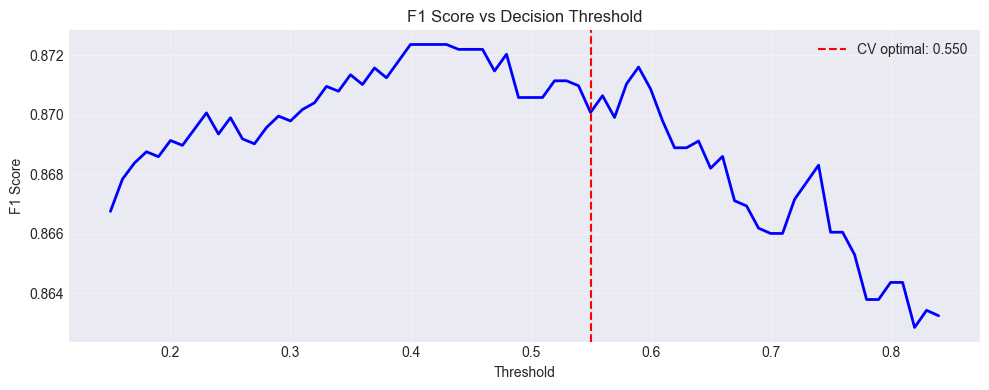

In [ ]:
# ============================================================
# OOF THRESHOLD TUNING FOR REPEATED GPU BLEND
# ============================================================
print("=" * 60)
print("OOF THRESHOLD TUNING: Repeated GPU Blend (LightGBM + XGBoost)")
print("=" * 60)

X_full = pd.concat([X_train_eng, X_val_eng], axis=0).reset_index(drop=True)
y_full = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)
X_test_blend = X_test_eng.reset_index(drop=True)

ensemble_seeds = [42, 52, 62]
ensemble_models = []
oof_pred_sum = np.zeros(len(X_full), dtype=float)
oof_pred_count = np.zeros(len(X_full), dtype=float)
test_pred_sum = np.zeros(len(X_test_blend), dtype=float)
fold_default_f1 = []

for seed in ensemble_seeds:
    skf_blend = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    for fold, (train_idx, val_idx) in enumerate(skf_blend.split(X_full, y_full), start=1):
        X_tr = X_full.iloc[train_idx]
        y_tr = y_full.iloc[train_idx]
        X_va = X_full.iloc[val_idx]
        y_va = y_full.iloc[val_idx]

        fold_imputer = SimpleImputer(strategy='median')
        X_tr_imp_fold = pd.DataFrame(
            fold_imputer.fit_transform(X_tr), columns=eng_feature_cols
        )
        X_va_imp_fold = pd.DataFrame(
            fold_imputer.transform(X_va), columns=eng_feature_cols
        )
        X_te_imp_fold = pd.DataFrame(
            fold_imputer.transform(X_test_blend), columns=eng_feature_cols
        )

        lgb_model = build_lgbm_model(random_state=seed + fold)
        xgb_model = build_xgb_model(random_state=seed + fold)

        lgb_model.fit(X_tr_imp_fold, y_tr)
        xgb_model.fit(X_tr_imp_fold, y_tr)

        lgb_va = lgb_model.predict_proba(X_va_imp_fold)[:, 1]
        xgb_va = xgb_model.predict_proba(X_va_imp_fold)[:, 1]
        blend_va = (
            gpu_model_weights['LightGBM'] * lgb_va +
            gpu_model_weights['XGBoost'] * xgb_va
        )

        lgb_test = lgb_model.predict_proba(X_te_imp_fold)[:, 1]
        xgb_test = xgb_model.predict_proba(X_te_imp_fold)[:, 1]
        blend_test = (
            gpu_model_weights['LightGBM'] * lgb_test +
            gpu_model_weights['XGBoost'] * xgb_test
        )

        oof_pred_sum[val_idx] += blend_va
        oof_pred_count[val_idx] += 1.0
        test_pred_sum += blend_test

        fold_f1 = f1_score(y_va, (blend_va >= 0.5).astype(int))
        fold_default_f1.append(fold_f1)
        ensemble_models.append({
            'seed': seed,
            'fold': fold,
            'imputer': fold_imputer,
            'lgbm': lgb_model,
            'xgb': xgb_model,
        })
        print(f"Seed {seed} Fold {fold}: default-threshold F1 = {fold_f1:.4f}")

oof_pred = oof_pred_sum / np.maximum(oof_pred_count, 1.0)
y_proba_test = test_pred_sum / len(ensemble_models)
cv_scores = np.array(fold_default_f1)
default_oof_f1 = f1_score(y_full, (oof_pred >= 0.5).astype(int))

thresholds = np.arange(0.20, 0.80, 0.01)
threshold_scores = [f1_score(y_full, (oof_pred >= t).astype(int)) for t in thresholds]
best_threshold_idx = int(np.argmax(threshold_scores))
optimal_threshold = float(thresholds[best_threshold_idx])
f1_optimal = float(threshold_scores[best_threshold_idx])
y_pred_optimal = (oof_pred >= optimal_threshold).astype(int)

best_name = 'GPUWeightedBlend'
best_model = best_name

print(f"\nDeployment model: {best_name}")
print(f"Blend weights: {gpu_model_weights}")
print(f"Stored ensemble members: {len(ensemble_models)}")
print(f"OOF F1 at default threshold (0.50): {default_oof_f1:.4f}")
print(f"OOF F1 at optimal threshold ({optimal_threshold:.3f}): {f1_optimal:.4f}")
print(f"OOF fold mean F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

plt.figure(figsize=(10, 4))
plt.plot(thresholds, threshold_scores, 'b-', linewidth=2)
plt.axvline(x=optimal_threshold, color='r', linestyle='--', label=f'Optimal: {optimal_threshold:.3f}')
plt.xlabel('Threshold')
plt.ylabel('OOF F1 Score')
plt.title('OOF F1 Score vs Decision Threshold (GPU Blend)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

FEATURE IMPORTANCE (LightGBM)

Top 25 features:
             feature  importance
 dist_nearest_neg_km        3382
              ws_std        2444
     knn_5_dist_mean        2423
            pdsi_std        2414
  dist_ratio_pos_neg        2397
 dist_nearest_pos_km        2393
   dist_diff_pos_neg        2382
              ppt_cv        2338
               ws_cv        2282
              aet_cv        2230
             soil_cv        2221
    knn_10_dist_mean        2132
      knn_5_dist_min        2132
 knn_25_weighted_occ        2089
 knn_50_weighted_occ        2068
    knn_50_dist_mean        1914
             pdsi_cv        1902
knn_100_weighted_occ        1891
                q_cv        1837
    knn_25_dist_mean        1811
            srad_std        1782
   knn_100_dist_mean        1747
              pet_cv        1721
 knn_10_weighted_occ        1682
          vap_median        1603


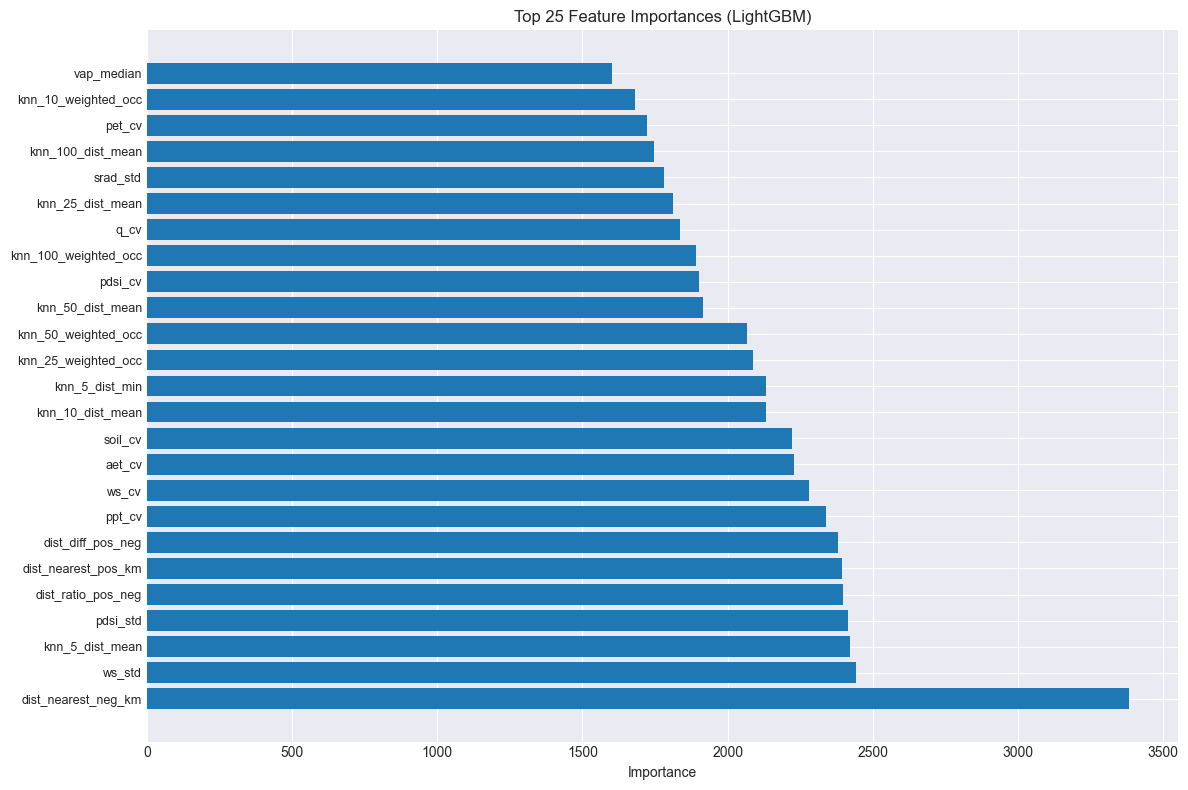

In [14]:
# ============================================================
# FEATURE IMPORTANCE ANALYSIS
# ============================================================
print("=" * 60)
print("FEATURE IMPORTANCE (LightGBM)")
print("=" * 60)

importance_df = pd.DataFrame({
    'feature': eng_feature_cols,
    'importance': best_lgbm.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 25 features:")
print(importance_df.head(25).to_string(index=False))

plt.figure(figsize=(12, 8))
top_n = min(25, len(importance_df))
plt.barh(range(top_n), importance_df['importance'].head(top_n).values)
plt.yticks(range(top_n), importance_df['feature'].head(top_n).values, fontsize=9)
plt.xlabel('Importance')
plt.title('Top 25 Feature Importances (LightGBM)')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# FINAL GPU BLEND ENSEMBLE ARTIFACTS
# ============================================================
print("=" * 60)
print("FINAL GPU BLEND ENSEMBLE READY")
print("=" * 60)

final_model = {
    'type': 'repeated_stratified_gpu_blend',
    'name': best_name,
    'weights': gpu_model_weights,
    'seeds': ensemble_seeds,
    'threshold': optimal_threshold,
    'members': ensemble_models,
    'feature_columns': eng_feature_cols,
}

print(f"Deployment model: {best_name}")
print(f"Ensemble members: {len(ensemble_models)}")
print(f"Blend weights: {gpu_model_weights}")
print(f"Optimal threshold: {optimal_threshold:.3f}")
print(f"OOF fold F1 mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"OOF F1 at optimal threshold: {f1_optimal:.4f}")

RETRAIN BEST MODEL ON 100% OF TRAINING DATA
Retraining LightGBM on 6312 samples...
Final model trained on full data!

5-fold CV on full training data:
CV F1 scores: [0.85677585 0.85277247 0.85640362 0.8833967  0.86850545]
Mean: 0.8636 ± 0.0112


In [ ]:
# ============================================================
# GENERATE TEST PREDICTIONS AND SUBMISSION FILE
# ============================================================
print("=" * 60)
print("GENERATING FINAL SUBMISSION")
print("=" * 60)

# y_proba_test comes from the repeated GPU blend ensemble above
y_pred_test = (y_proba_test >= optimal_threshold).astype(int)

print(f"Deployment model: {best_name}")
print(f"Threshold used: {optimal_threshold:.3f}")
print(f"Ensemble members used: {len(ensemble_models)}")
print(f"Prediction distribution:")
print(f"  No Frog (0): {np.sum(y_pred_test == 0)}")
print(f"  Frog (1):    {np.sum(y_pred_test == 1)}")

submission = pd.DataFrame({
    'ID': test_ids.values,
    'Target': y_pred_test
})

print(f"\nSubmission shape: {submission.shape}")
print(submission.head(10))

submission_file = f'Submission_Final_{best_name}_t{optimal_threshold:.2f}.csv'
submission.to_csv(submission_file, index=False)
print(f"\n✓ Submission saved: {submission_file}")

submission.to_csv('Predicted_Data.csv', index=False)
print("✓ Also saved as: Predicted_Data.csv")

GENERATING FINAL SUBMISSION
Threshold used: 0.550
Prediction distribution:
  No Frog (0): 675
  Frog (1):    1325

Submission shape: (2000, 2)
             ID  Target
0  ID_TS_54240C       1
1  ID_TS_EF9635       0
2  ID_TS_4E63E6       0
3  ID_TS_FDAB8E       0
4  ID_TS_E00D49       1
5  ID_TS_A52A64       0
6  ID_TS_CFB5DB       1
7  ID_TS_CA468C       1
8  ID_TS_52FAAF       0
9  ID_TS_08039A       1

✓ Submission saved: Submission_Final_LightGBM_t0.55.csv
✓ Also saved as: Predicted_Data.csv


In [ ]:
# ============================================================
# FINAL SUMMARY
# ============================================================
print("=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print(f"\nValidation Model Comparison:")
print(f"  LightGBM (Optuna):      F1 = {f1_lgbm:.4f}")
print(f"  XGBoost  (Optuna):      F1 = {f1_xgb:.4f}")
print(f"  Random Forest:          F1 = {f1_rf:.4f}")
print(f"  Stacking Ensemble:      F1 = {f1_stack:.4f}")

print(f"\nDeployment Model: {best_name}")
print(f"Blend weights: {gpu_model_weights}")
print(f"Optimal Threshold: {optimal_threshold:.3f}")
print(f"OOF Fold F1 Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"OOF F1 at Optimal Threshold: {f1_optimal:.4f}")
print(f"Ensemble members: {len(ensemble_models)}")
print(f"Submission file: {submission_file}")

joblib.dump(final_model, f'final_model_{best_name}.pkl')
joblib.dump(eng_feature_cols, 'final_feature_cols.pkl')
print("\n✓ Model artifacts saved")
print("=" * 60)

FINAL SUMMARY

Model Performance (Validation Set):
  LightGBM (Optuna):      F1 = 0.8706
  XGBoost  (Optuna):      F1 = 0.8662
  Random Forest:          F1 = 0.8560
  Stacking Ensemble:      F1 = 0.8660
  + Threshold Tuning:     F1 = 0.8701

Best Model: LightGBM
Optimal Threshold: 0.550
CV Mean F1 (full data): 0.8636 ± 0.0112
Submission file: Submission_Final_LightGBM_t0.55.csv

✓ Model artifacts saved


## (Optional) Additional Analysis Below
The cells below are kept for reference and are NOT needed for the main pipeline above.

In [18]:
print(f"LightGBM best F1: {study.best_value:.4f}")
print(f"XGBoost best F1: {study_xgb.best_value:.4f}")
print(f"Eng features: {len(eng_feature_cols)}")
print(f"X_train_imp shape: {X_train_imp.shape}")
print(f"X_val_imp shape: {X_val_imp.shape}")

LightGBM best F1: 0.8576
XGBoost best F1: 0.8579
Eng features: 87
X_train_imp shape: (5049, 87)
X_val_imp shape: (1263, 87)


In [19]:
# (Legacy) Quick model comparison — already done above
print("See model comparison in the main pipeline above.")

See model comparison in the main pipeline above.


In [20]:
# (Legacy) Feature importance — already plotted above
print("See feature importance chart in the main pipeline above.")

See feature importance chart in the main pipeline above.


---
### Legacy cells below (predictions and submissions already generated above)

In [21]:
print("Predictions already generated. See Predicted_Data.csv")

Predictions already generated. See Predicted_Data.csv


## Section 9: Create and Save Submission File

Format predictions into the required submission format.

In [22]:
print("Submission already saved. See above.")

Submission already saved. See above.


In [23]:
print("Model artifacts already saved. See above.")

Model artifacts already saved. See above.


## Summary

### Pipeline Overview
1. Load training/test CSVs
2. Extract **all** TerraClimate bands (median + std) from GeoTIFF
3. Add **spatial KNN occurrence features** from nearby labeled records
4. Feature engineering: geographic encoding, hydrology and temperature ratios, aggregate stats, temporal CV
5. **Optuna** hyperparameter tuning for LightGBM and XGBoost
6. Random Forest and stacking used as comparison models
7. Build a **GPU deployment blend** from LightGBM + XGBoost
8. Use **repeated stratified folds** to create out-of-fold probabilities and average test probabilities
9. Tune the final decision threshold on the blend's OOF predictions
10. Generate submission with the optimized threshold

### Key Improvements In This Version
- Keeps the strong **spatial KNN** signal in the feature set
- Adds more **domain-driven climate interactions** and ratios
- Runs both **LightGBM and XGBoost on GPU**
- Uses a more robust **repeated fold ensemble** instead of deploying a single refit model
- Tunes threshold on **OOF blended probabilities**, which is more stable than a single validation split

---
### Legacy iteration cells below (kept for reference only, do NOT run)

In [24]:
# Legacy: Old threshold tuning iteration (superseded by CV-based tuning above)
pass

In [25]:
# Legacy: Old iteration 4 submission
pass

In [26]:
# Legacy: Old iteration 5 submission
pass

In [27]:
# Legacy: Old SMOTE iteration
pass

In [28]:
# Legacy: Old SMOTE submission
pass